#Collection, Loading and Analysis of FOMC Dataset.

## Step One: Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Step two : Install datasets and loading Dataset from huggingface

In [2]:
pip install datasets

In [3]:
from datasets import load_dataset

In [4]:
dataset = load_dataset("vtasca/fomc-statements-minutes") ## Loading FOMC dataset

README.md: 0.00B [00:00, ?B/s]

communications.csv:   0%|          | 0.00/12.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/461 [00:00<?, ? examples/s]

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['Date', 'Release Date', 'Type', 'Text'],
        num_rows: 461
    })
})


## Step three : FOMC Dataset Analysis

In [6]:
## Converting to Python dataframe for processing.

fomc_df = dataset["train"].to_pandas()

In [7]:
##Checking first few records

fomc_df.head()

,Date,Release Date,Type,Text
0,2026-03-18,2026-03-18,Statement,Available indicators suggest that economic act...
1,2026-01-28,2026-01-28,Statement,Available indicators suggest that economic act...
2,2026-01-28,2026-02-18,Minute,Minutes of the Federal Open Market Committee\n...
3,2025-12-10,2025-12-10,Statement,Available indicators suggest that economic act...
4,2025-12-10,2025-12-30,Minute,Minutes of the Federal Open Market Committee\n...


In [8]:
fomc_df.shape ## Number of rows and columns check

(461, 4)

### There are four collumns in dataset and total 458 rows/records and 5 columns.

In [9]:
## Check for missing values
fomc_df.isnull().sum() ## ## RElease date have 29 null values

,0
Date,0
Release Date,29
Type,0
Text,0


In [10]:
## Check inofmration of FOMC columns
fomc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          461 non-null    object
 1   Release Date  432 non-null    object
 2   Type          461 non-null    object
 3   Text          461 non-null    object
dtypes: object(4)
memory usage: 14.5+ KB


Release Date column have null values

In [11]:
fomc_df['Release Date'].describe()

,Release Date
count,432
unique,429
top,2007-10-09
freq,3


### Record spans from Feb 2000 to Dec 2025 with latest record of 10 Dec 2025.

In [12]:
##Checking sample text record of Minute
fomc_df['Text'][0]

"Available indicators suggest that economic activity has been expanding at a solid pace. Job gains have remained low, and the unemployment rate has been little changed in recent months. Inflation remains somewhat elevated.\n\nThe Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run. Uncertainty about the economic outlook remains elevated. The implications of developments in the Middle East for the U.S. economy are uncertain. The Committee is attentive to the risks to both sides of its dual mandate.\n\nIn support of its goals, the Committee decided to maintain the target range for the federal funds rate at 3â\x80\x911/2 to 3â\x80\x913/4 percent. In considering the extent and timing of additional adjustments to the target range for the federal funds rate, the Committee will carefully assess incoming data, the evolving outlook, and the balance of risks. The Committee is strongly committed to supporting maximum employment and returning in

In [13]:
##Checking sample text record of Statement
fomc_df['Text'][1]

"Available indicators suggest that economic activity has been expanding at a solid pace. Job gains have remained low, and the unemployment rate has shown some signs of stabilization. Inflation remains somewhat elevated.\n\nThe Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run. Uncertainty about the economic outlook remains elevated. The Committee is attentive to the risks to both sides of its dual mandate.\n\nIn support of its goals, the Committee decided to maintain the target range for the federal funds rate at 3â\x80\x911/2 to 3â\x80\x913/4 percent. In considering the extent and timing of additional adjustments to the target range for the federal funds rate, the Committee will carefully assess incoming data, the evolving outlook, and the balance of risks. The Committee is strongly committed to supporting maximum employment and returning inflation to its 2 percent objective.\n\nIn assessing the appropriate stance of monetary poli

### Statement is less lengthy as compared to  minutes of FOMC.

In [14]:
print('Count of Minutes -',fomc_df[fomc_df['Type']=='Minute'].shape[0])
print('Count of Statements -',fomc_df[fomc_df['Type']=='Statement'].shape[0])

Count of Minutes - 239
Count of Statements - 222


There are 238 Minutes and 220 Statements in dataset.

### A] EDA of FOMC dataset

In [15]:
## Converting object types to datetime of Release Date and Release Year column as they contain date values.

fomc_df['Release Date'] = pd.to_datetime(fomc_df['Release Date'])
fomc_df['Date'] = pd.to_datetime(fomc_df['Date'])

In [16]:
## To analyse days difference between Release date and actul date of communication.

fomc_df['Date Difference'] = (fomc_df['Release Date'] - fomc_df['Date']).dt.days
fomc_df['Date Difference']=fomc_df['Date Difference'].round().astype('Int64')
fomc_df['Date Difference'].value_counts().sort_index(ascending=False)

,count
Date Difference,
60,1
58,3
57,2
54,1
51,9
50,7
44,11
43,1
37,3


Maximum difference in days between actual communication date and release date of Minute is 60 days.
<br>However, 149 minutes have difference days of 21 days.

In [17]:
fomc_df[fomc_df['Type']=='Statement']['Date Difference'].value_counts() ## Analysing date differences of Statement

,count
Date Difference,
0,221
7,1


In [18]:
fomc_df[fomc_df['Type']=='Minute']['Date Difference'].value_counts() ## Analysing date differences of Minute

,count
Date Difference,
21,150
44,11
51,9
20,8
22,8
50,7
36,3
37,3
58,3


Statements are release on same date when meeting is conducted, however Minutes are released 21 days post the actual communication date.

In [19]:
## Adding a column of Release year to get year from date of release.

fomc_df['Release Year']=fomc_df['Release Date'].dt.year
fomc_df['Release Year']=fomc_df['Release Year'].round().astype('Int64')

In [20]:
fomc_df['Release Year'].value_counts() ## Can see release frequency were highest in 2007.

,count
Release Year,
2007,20
2008,19
2001,19
2010,17
2025,17
2019,17
2020,17
2021,16
2024,16


In [21]:
## Amending the Release date of Statement record having Date difference as '7' to rectify outlier.

fomc_df[(fomc_df['Date Difference']==7)& (fomc_df['Type']=='Statement')] ## To get the index location of the record


,Date,Release Date,Type,Text,Date Difference,Release Year
107,2019-10-04,2019-10-11,Statement,Consistent with its January 2019 Statement Reg...,7,2019


In [22]:
fomc_df.loc[104,'Release Date'] = fomc_df.loc[104,'Date']  ## To keep the release date of Statement record same as of actual date.
fomc_df['Date Difference'] = (fomc_df['Release Date'] - fomc_df['Date']).dt.days ## To update the date difference.
fomc_df[(fomc_df['Date Difference']==7)& (fomc_df['Type']=='Statement')] ## To check if successfully updated

,Date,Release Date,Type,Text,Date Difference,Release Year
107,2019-10-04,2019-10-11,Statement,Consistent with its January 2019 Statement Reg...,7.0,2019


In [23]:
fomc_df['Date Difference']=fomc_df['Date Difference'].round().astype('Int64')
fomc_df[fomc_df['Type']=='Statement']['Date Difference'].value_counts() ## Analysing date differences of Statement


,count
Date Difference,
0,221
7,1


Now we have all statements with date difference as 0.

In [24]:
## Analysis of records having null values in Release date
fomc_df[fomc_df['Release Date'].isna()]['Type'].value_counts()  ## Can see for records that have 'null' Release Dates are all Minutes.


,count
Type,
Minute,29


In [25]:
## For null values of Release Date of Minutes, updating the value with difference of 21 days from actual date as most of the minutes have difference of 21 days.
ind_list = fomc_df[fomc_df['Release Date'].isna()].index.tolist()  ### Row index to update
for i in ind_list:
    fomc_df.loc[i,'Release Date'] = fomc_df.loc[i,'Date'] + pd.Timedelta(days=21)

fomc_df[fomc_df['Release Date'].isna()] ## To check if any null values present



,Date,Release Date,Type,Text,Date Difference,Release Year


In [26]:
fomc_df['Date Difference'] = (fomc_df['Release Date'] - fomc_df['Date']).dt.days ## To update the date difference.
fomc_df['Release Year']=fomc_df['Release Date'].dt.year                          ## To update Release year
fomc_df['Release Year']=fomc_df['Release Year'].round().astype('Int64')


In [27]:
## Checking if any null values are present

fomc_df.isna().sum()

,0
Date,0
Release Date,0
Type,0
Text,0
Date Difference,0
Release Year,0


There are no null values and outliers are handled in FOMC dataset.

In [28]:
## To save the updated dataset into local excel sheet for future references.
fomc_df.to_excel(r'C:\Users\prapt\Documents\fomc_output.xlsx', index=False)

## Visualisation of dataset

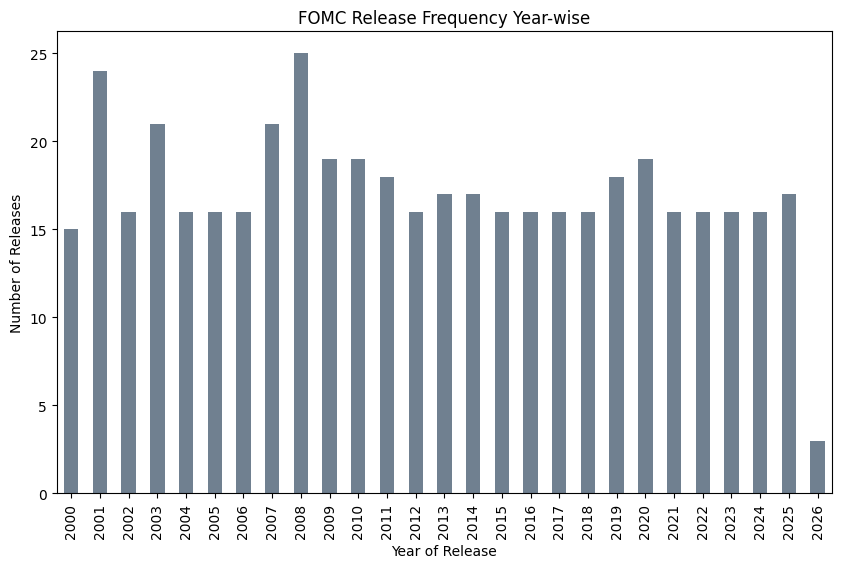

In [29]:
## Chart of release frequency year-wise.

fomc_df['Release Year'].value_counts().sort_index().plot(kind='bar',color='Slategray',figsize=(10, 6))
plt.title('FOMC Release Frequency Year-wise')
plt.xlabel('Year of Release')
plt.ylabel('Number of Releases')
plt.show()


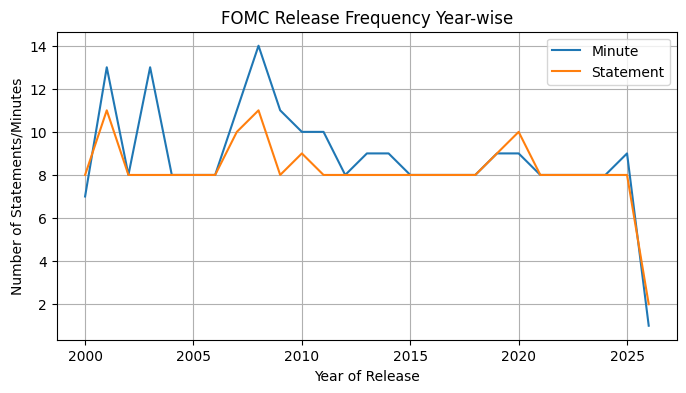

In [30]:
fomc_df[fomc_df['Type']=='Minute']['Release Year'].value_counts().sort_index().plot(kind='line', figsize=(8, 4), label='Minute')
fomc_df[fomc_df['Type']=='Statement']['Release Year'].value_counts().sort_index().plot(kind='line', figsize=(8, 4), label='Statement')
plt.title('FOMC Release Frequency Year-wise')
plt.xlabel('Year of Release')
plt.ylabel('Number of Statements/Minutes')
plt.legend()
plt.grid(True)
plt.show()


Findings :

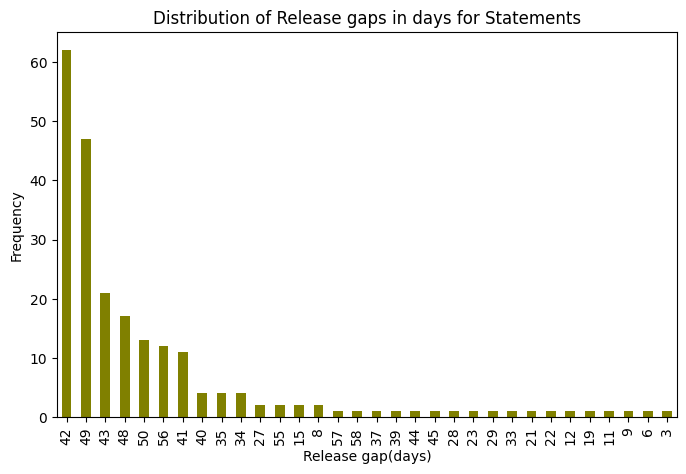

In [31]:
  ## To plot gaps between release frequency of Statements.

  fomc_df[fomc_df['Type']=='Statement'].sort_values('Release Date')['Release Date'].diff().dt.days.astype('Int64')[1:].sort_values(ascending=False).value_counts()\
                                    .plot(kind='bar',color='olive',figsize=(8,5))
  plt.title('Distribution of Release gaps in days for Statements')
  plt.xlabel('Release gap(days)')
  plt.ylabel('Frequency')
  plt.show()

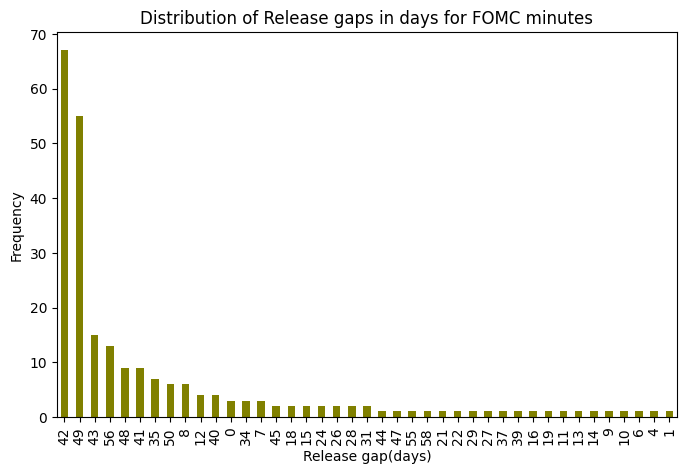

In [32]:
  ## To plot gaps between release frequency of Minutes.

  fomc_df[fomc_df['Type']=='Minute'].sort_values('Release Date')['Release Date'].diff().dt.days.astype('Int64')[1:].sort_values(ascending=False).value_counts()\
                                    .plot(kind='bar',color='olive',figsize=(8,5))
  plt.title('Distribution of Release gaps in days for FOMC minutes')
  plt.xlabel('Release gap(days)')
  plt.ylabel('Frequency')
  plt.show()

In [33]:
## To check average length of Minute and Statements required for analysis.
## Creating new datframe capturing number of words in Minutes and Statements.

fomc_length_df = fomc_df[['Type','Release Date','Release Year']]  ## To copy only required column.


In [34]:
## To calculate length by words count in document.
for i in fomc_df.index:
  fomc_length_df.loc[i,'Word_Count']=len(fomc_df['Text'][i].split())

In [35]:
fomc_length_df.head()

,Type,Release Date,Release Year,Word_Count
0,Statement,2026-03-18,2026,322.0
1,Statement,2026-01-28,2026,308.0
2,Minute,2026-02-18,2026,6580.0
3,Statement,2025-12-10,2025,402.0
4,Minute,2025-12-30,2025,7649.0


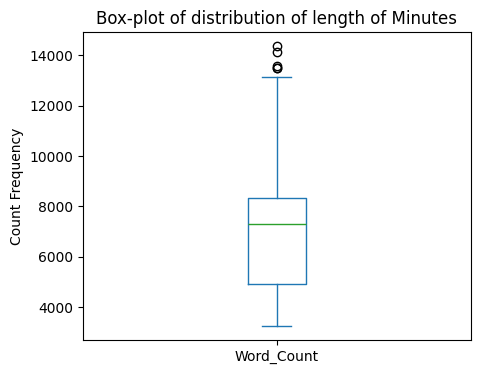


 Below is the percentile distribution of Minute length based on word count :-



,Word_Count
count,239.000000
mean,7135.878661
std,2381.441308
min,3237.000000
10%,3975.800000
20%,4518.600000
50%,7298.000000
75%,8328.500000
80%,8675.200000
90%,9957.200000


In [36]:
## Visulaisation of word count distribution of Minutes based on word-count

fomc_length_df[fomc_length_df['Type']=='Minute']['Word_Count'].plot(kind='box',figsize=(5,4))
plt.title('Box-plot of distribution of length of Minutes')
plt.ylabel('Count Frequency')
plt.show()
print('\n Below is the percentile distribution of Minute length based on word count :-\n')
fomc_length_df[fomc_length_df['Type']=='Minute']['Word_Count'].describe(percentiles=[0.10, 0.20, 0.50, 0.75, 0.80, 0.9,0.99])


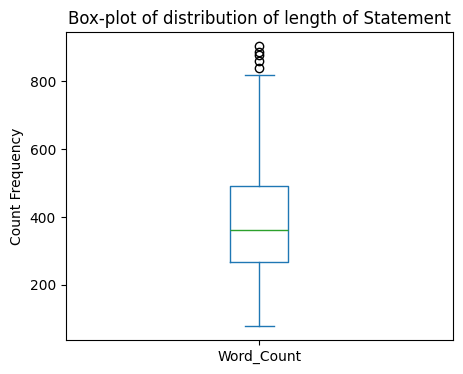


 Below is the percentile distribution of Statement length based on word count :-



,Word_Count
count,222.000000
mean,393.432432
std,168.331612
min,78.000000
10%,204.000000
20%,231.400000
50%,361.500000
75%,491.000000
80%,535.000000
90%,595.600000


In [37]:
## Visulaisation of word count distribution of Statements based on word-count

fomc_length_df[fomc_length_df['Type']=='Statement']['Word_Count'].plot(kind='box',figsize=(5,4))
plt.title('Box-plot of distribution of length of Statement')
plt.ylabel('Count Frequency')
plt.show()
print('\n Below is the percentile distribution of Statement length based on word count :-\n')
fomc_length_df[fomc_length_df['Type']=='Statement']['Word_Count'].describe(percentiles=[0.10, 0.20, 0.50, 0.75, 0.80, 0.9,0.99])

In [38]:
## To check number of sentences in Minutes and Statements.
## Importing NLTK's punkt_tab tokenizer for sentence detection.

import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [39]:
from nltk.tokenize import sent_tokenize

for i in fomc_df.index:
  fomc_length_df.loc[i,'Sentence_Count']=len(sent_tokenize(fomc_df['Text'][i]))


In [40]:
fomc_length_df.head()

,Type,Release Date,Release Year,Word_Count,Sentence_Count
0,Statement,2026-03-18,2026,322.0,17.0
1,Statement,2026-01-28,2026,308.0,16.0
2,Minute,2026-02-18,2026,6580.0,218.0
3,Statement,2025-12-10,2025,402.0,18.0
4,Minute,2025-12-30,2025,7649.0,246.0


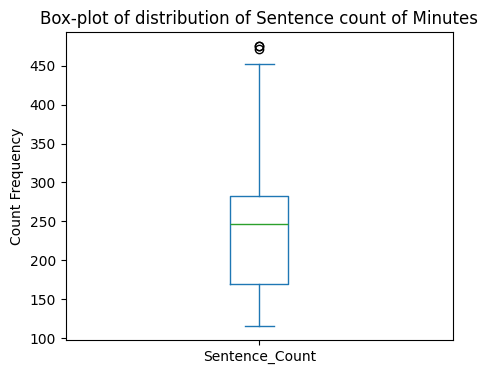


 Below is the percentile distribution of Minute length based on Sentence count :-



,Sentence_Count
count,239.000000
mean,244.372385
std,77.675631
min,115.000000
10%,140.000000
20%,159.600000
50%,246.000000
75%,282.500000
80%,297.400000
90%,337.000000


In [41]:
## Visulaisation of sentence count distribution of Minutes based on word-count

fomc_length_df[fomc_length_df['Type']=='Minute']['Sentence_Count'].plot(kind='box',figsize=(5,4))
plt.title('Box-plot of distribution of Sentence count of Minutes')
plt.ylabel('Count Frequency')
plt.show()
print('\n Below is the percentile distribution of Minute length based on Sentence count :-\n')
fomc_length_df[fomc_length_df['Type']=='Minute']['Sentence_Count'].describe(percentiles=[0.10, 0.20, 0.50, 0.75, 0.80, 0.9,0.99])


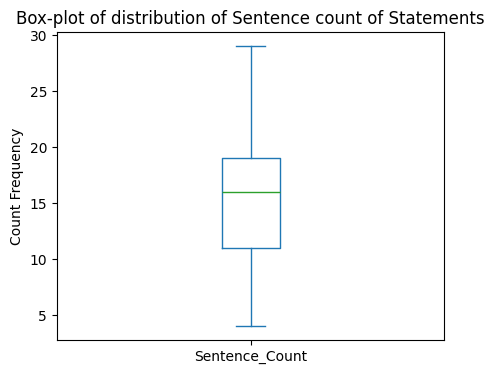


 Below is the percentile distribution of Statement length based on Sentence count :-



,Sentence_Count
count,222.000000
mean,15.315315
std,5.514246
min,4.000000
10%,8.000000
20%,10.000000
50%,16.000000
75%,19.000000
80%,20.000000
90%,22.000000


In [42]:
## Visulaisation of sentence count distribution of Statements based on word-count

fomc_length_df[fomc_length_df['Type']=='Statement']['Sentence_Count'].plot(kind='box',figsize=(5,4))
plt.title('Box-plot of distribution of Sentence count of Statements')
plt.ylabel('Count Frequency')
plt.show()
print('\n Below is the percentile distribution of Statement length based on Sentence count :-\n')
fomc_length_df[fomc_length_df['Type']=='Statement']['Sentence_Count'].describe(percentiles=[0.10, 0.20, 0.50, 0.75, 0.80, 0.9,0.99])


## B] Word Cloud Analysis of FOMC Statements and Meeting Minutes.


In [43]:
## Pre-processing of text.
import re

fomc_clean_df=pd.DataFrame()
for i in fomc_df.index:
  fomc_clean_df.loc[i,'Cleaned_Text']=fomc_df['Text'][i].lower()  ## Lowercasing text
  fomc_clean_df.loc[i,'Cleaned_Text']=re.sub(r'[^A-Za-z0-9\s]','',fomc_clean_df['Cleaned_Text'][i])  ## REmoving puinctuation
  fomc_clean_df.loc[i,'Cleaned_Text']=re.sub(r'\b\w*\d\w*\b','',fomc_clean_df['Cleaned_Text'][i])  ## Removing numbers
  fomc_clean_df.loc[i,'Cleaned_Text']=re.sub(r'\n+\t+','',fomc_clean_df['Cleaned_Text'][i])  ## Removing empty lines
  fomc_clean_df.loc[i,'Type']=fomc_df['Type'][i]  ## To keep Type column for future references.



In [44]:
## Lematizing word text post cleaning step

import en_core_web_sm
nlp = en_core_web_sm.load()

for i in fomc_clean_df.index:
  wrd_lst=nlp(fomc_clean_df['Cleaned_Text'][i])
  token=[]
  for wrd in wrd_lst:
    token.append(wrd.lemma_)
    fomc_clean_df.loc[i,'Cleaned_Text']=" ".join(token)

#### Lematization took 12 mins to complete

In [45]:
## Stopword Removal

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


for i in fomc_clean_df.index:
  word_tokens=[]
  word_tokens = word_tokenize(fomc_clean_df['Cleaned_Text'][i])
  filtered_text = [word for word in word_tokens if word.lower() not in stop_words]
  fomc_clean_df.loc[i,'Cleaned_Text']=" ".join(filtered_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### Word Coud Visualisation of frequently used words in FOMC.

In [46]:
## Word Cloud visualisation

from collections import Counter
all_txt = ' '.join(fomc_clean_df['Cleaned_Text'])
txt_freq = Counter(all_txt.split())

## Find top 50 most frequency occuring word.
top_50_freq_words = dict(txt_freq.most_common(50))
top_50_freq_words


{'market': 15284,
 'committee': 14514,
 'rate': 13229,
 'inflation': 13155,
 'federal': 12336,
 'economic': 10189,
 'participant': 9874,
 'policy': 8838,
 'price': 8829,
 'continue': 7777,
 'reserve': 7419,
 'board': 7394,
 'remain': 7389,
 'increase': 7301,
 'bank': 7103,
 'would': 6877,
 'growth': 6162,
 'monetary': 6035,
 'condition': 5916,
 'financial': 5882,
 'percent': 5111,
 'decline': 5051,
 'period': 5011,
 'meeting': 4947,
 'year': 4905,
 'quarter': 4900,
 'security': 4882,
 'labor': 4774,
 'recent': 4769,
 'level': 4645,
 'fund': 4567,
 'risk': 4436,
 'business': 4274,
 'open': 4261,
 'rise': 4247,
 'low': 4150,
 'member': 4121,
 'activity': 4022,
 'governor': 4001,
 'outlook': 3984,
 'consumer': 3969,
 'foreign': 3906,
 'month': 3880,
 'division': 3855,
 'pace': 3854,
 'expect': 3841,
 'also': 3680,
 'note': 3642,
 'expectation': 3231,
 'balance': 3228}

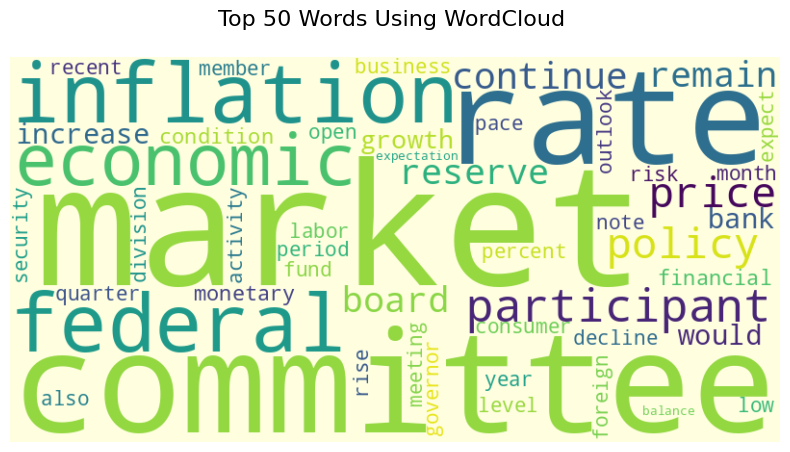

In [47]:
# Creating Word Cloud
!pip install wordcloud
from wordcloud import WordCloud
wrdcld = WordCloud(width=800, height=400, background_color='lightyellow', colormap='viridis').generate_from_frequencies(top_50_freq_words)

# Visualize the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wrdcld, interpolation='bilinear')
plt.axis("off")
plt.title("Top 50 Words Using WordCloud \n", fontsize=16)
plt.show()

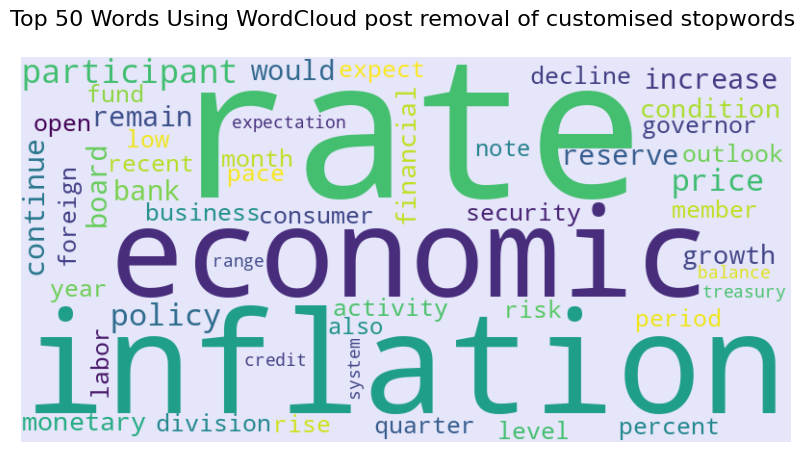

In [48]:
## Customising stop words to exclude non-important domain specific words.

custom_stop_words = ['meeting','committee','statement','minute','market','fomc','federal']
stop_words.update(custom_stop_words)

for i in fomc_clean_df.index:
  word_tokens=[]
  word_tokens = word_tokenize(fomc_clean_df['Cleaned_Text'][i])
  filtered_text = [word for word in word_tokens if word.lower() not in stop_words]
  fomc_clean_df.loc[i,'Cleaned_Text']=" ".join(filtered_text)


txt_frq_new = Counter((' '.join(fomc_clean_df['Cleaned_Text'])).split())

wrdcld = WordCloud(width=800, height=400, background_color='lavender', colormap='viridis').generate_from_frequencies(dict(txt_frq_new.most_common(50)))

# Visualize the Word Cloud using custom stopwords
plt.figure(figsize=(10, 5))
plt.imshow(wrdcld, interpolation='bilinear')
plt.axis("off")
plt.title("Top 50 Words Using WordCloud post removal of customised stopwords \n", fontsize=16)
plt.show()

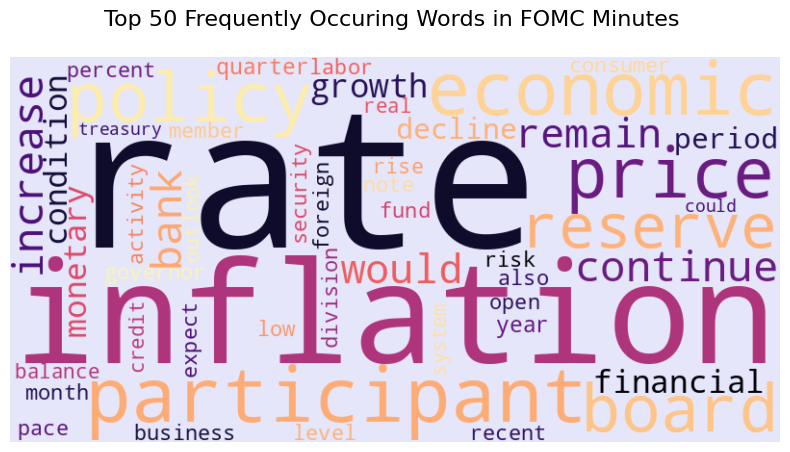

In [49]:
# Visualize the Word frequncy by word Cloud on Minutes.

wrd_frq_minute=Counter((' '.join(fomc_clean_df[fomc_clean_df['Type']=='Minute']['Cleaned_Text'])).split())
wrdcld = WordCloud(width=800, height=400, background_color='lavender', colormap='magma').generate_from_frequencies(dict(wrd_frq_minute.most_common(50)))

# Visualize the Word Cloud using custom stopwords
plt.figure(figsize=(10, 5))
plt.imshow(wrdcld, interpolation='bilinear')
plt.axis("off")
plt.title("Top 50 Frequently Occuring Words in FOMC Minutes \n", fontsize=16)
plt.show()

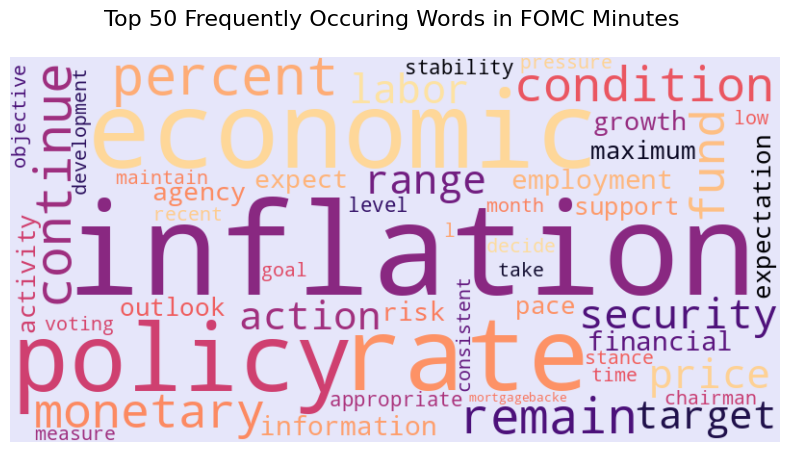

In [50]:
# Visualize the Word frequncy by word Cloud on Statements.

wrd_frq_stmt=Counter((' '.join(fomc_clean_df[fomc_clean_df['Type']=='Statement']['Cleaned_Text'])).split())
wrdcld = WordCloud(width=800, height=400, background_color='lavender', colormap='magma').generate_from_frequencies(dict(wrd_frq_stmt.most_common(50)))

# Visualize the Word Cloud using custom stopwords
plt.figure(figsize=(10, 5))
plt.imshow(wrdcld, interpolation='bilinear')
plt.axis("off")
plt.title("Top 50 Frequently Occuring Words in FOMC Minutes \n", fontsize=16)
plt.show()

### Bi-Gram word pair frequency in FOMC.

In [51]:
## To create Bi-Gram(pair of words) of preprocessed words for Minutes type.
text_corpus_min=(' '.join(fomc_clean_df[fomc_clean_df['Type']=='Minute']['Cleaned_Text'])).split()  ## Bi-Gram from FOMC minutes
wrd_bigram = [(text_corpus_min[i], text_corpus_min[i + 1]) for i in range(len(text_corpus_min) - 1)]

## To find top 30 bigram frequncy.

wrd_bigram_freq = Counter(wrd_bigram)
wrd_bigram_top_30 = dict(wrd_bigram_freq.most_common(30))

#Print the top 10 words in the bigram frequency

print('Top 15 words in the bigram frequency:-\n')
list(wrd_bigram_top_30)[0:15]


Top 15 words in the bigram frequency:-



[('board', 'governor'),
 ('reserve', 'bank'),
 ('fund', 'rate'),
 ('monetary', 'policy'),
 ('intermeete', 'period'),
 ('economic', 'activity'),
 ('director', 'division'),
 ('inflation', 'expectation'),
 ('monetary', 'affair'),
 ('division', 'monetary'),
 ('affair', 'board'),
 ('president', 'reserve'),
 ('unemployment', 'rate'),
 ('participant', 'note'),
 ('new', 'york')]

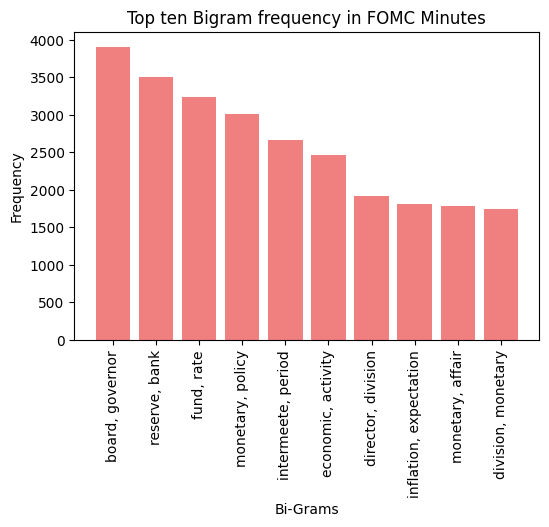

In [52]:
## Plot of Top 10 Bigram frequency to visualize dsitribution of words pair in FOMC Minutes.

values=list(wrd_bigram_top_30.values())[0:10]    ## Extracting frequency values in list.
keys=[', '.join(val) for val in list(wrd_bigram_top_30.keys())[0:10]]   ## Extracting bi-gram term in a list.

plt.figure(figsize=(6, 4))
plt.bar(keys, values, color='lightcoral')
plt.xticks(rotation=90)
plt.xlabel('Bi-Grams')
plt.ylabel('Frequency')
plt.title('Top ten Bigram frequency in FOMC Minutes')
plt.show()

In [53]:
## To create Bi-Gram(pair of words) of preprocessed words for Statement type.
text_corpus_stmt=(' '.join(fomc_clean_df[fomc_clean_df['Type']=='Statement']['Cleaned_Text'])).split()  ## Bi-Gram from FOMC Statements
wrd_bigram = [(text_corpus_stmt[i], text_corpus_stmt[i + 1]) for i in range(len(text_corpus_stmt) - 1)]

## To find top 30 bigram frequncy.

wrd_bigram_freq = Counter(wrd_bigram)
wrd_bigram_top_30 = dict(wrd_bigram_freq.most_common(30))

#Print the top 10 words in the bigram frequency

print('Top 15 words in the bigram frequency:-\n')
list(wrd_bigram_top_30)[0:15]


Top 15 words in the bigram frequency:-



[('monetary', 'policy'),
 ('fund', 'rate'),
 ('target', 'range'),
 ('maximum', 'employment'),
 ('inflation', 'expectation'),
 ('economic', 'activity'),
 ('price', 'stability'),
 ('range', 'fund'),
 ('labor', 'condition'),
 ('rate', 'percent'),
 ('policy', 'action'),
 ('stance', 'monetary'),
 ('agency', 'mortgagebacke'),
 ('mortgagebacke', 'security'),
 ('voting', 'monetary')]

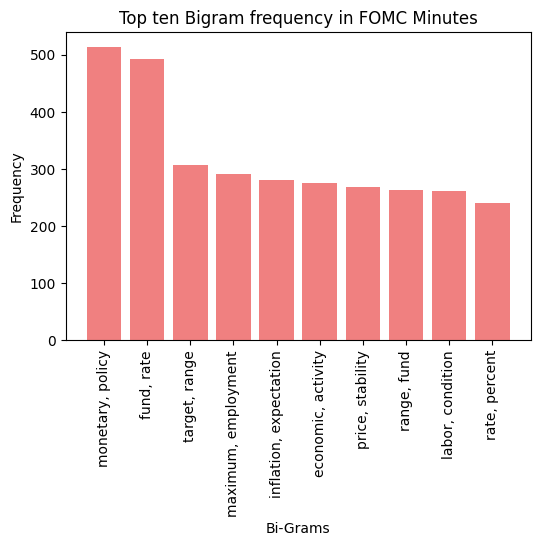

In [54]:
## Plot of Top 10 Bigram frequency to visualize dsitribution of words pair in FOMC Statements.

values=list(wrd_bigram_top_30.values())[0:10]    ## Extracting frequency values in list.
keys=[', '.join(val) for val in list(wrd_bigram_top_30.keys())[0:10]]   ## Extracting bi-gram term in a list.

plt.figure(figsize=(6, 4))
plt.bar(keys, values, color='lightcoral')
plt.xticks(rotation=90)
plt.xlabel('Bi-Grams')
plt.ylabel('Frequency')
plt.title('Top ten Bigram frequency in FOMC Minutes')
plt.show()

## Topic Moeling omn FOMC data corpus to identify the dominating topics/terms.


In [55]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

tfidf_vectorize = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2) ## To extract features from corpus

## max_df and min_df are used to ignore words that appear more than 95% of documents and appear less than 2 in documents.


In [56]:
## Creating document list.
doc = list((fomc_clean_df[fomc_clean_df['Type']=='Statement']['Cleaned_Text']))

# To create TF-IDF matrix of document.
tfidf = tfidf_vectorize.fit_transform(doc)

## Create dataframe of tfidf matrix.
tfidf_df = pd.DataFrame(tfidf.toarray())

## Extracting feature names.
cols = tfidf_vectorize.get_feature_names_out()
tfidf_df.columns=cols
print(len(doc)) ## Check number of FOMC statements
tfidf_df

222


,abate,ability,abroad,absent,accelerate,acceptable,accessibility,accommodate,accommodation,accommodative,...,william,williams,window,winter,work,worker,world,year,yellen,york
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.066182,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.066626,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.055377,0.0,0.0,0.0,0.000000,0.0,0.105684,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.058850,0.0,0.0,0.0,0.000000,0.0,0.112310,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.062380,0.0,0.0,0.0,0.000000,0.0,0.059524,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.196479,0.0,0.000000,0.0,0.000000
218,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.187340,0.0,0.073197,0.0,0.000000
219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
220,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.090224


### There are 220 statements document and 1048 terms in the statements corpus.

## Topic Modeling by NMF (Non-negative matrix factorization) algorithm.

In [57]:
from sklearn.decomposition import NMF

## considering 5 topics to identify.
num_topics = 5
nmf_model = NMF(n_components=num_topics, random_state=40)  #write your code here

In [58]:
##Generating Doc-Topic matrix and Topic-Term matrix using NMF.

W = nmf_model.fit_transform(tfidf)  ## W is Doc-topic matirx
H = nmf_model.components_           ## H is topic-term matirx


print('Rows and Column of W matrix: ',np.shape(W))  ## W matrix is of dimension 21072 X 5
print('Rows and Column of H matrix: ',np.shape(H))  ## H matrix is of dimension 5 X 6767


Rows and Column of W matrix:  (222, 5)
Rows and Column of H matrix:  (5, 1050)


In [59]:
##Listing out top 15 terms(based on highest value) of each topic row .

word=np.zeros((5,15)).astype('str')

cols=tfidf_vectorize.get_feature_names_out()

for i in range(0,num_topics):
        word[i]=(cols[np.argsort(H[i])[::-1]][:15])

## Creating dataframe of top 15 words of each topic.

pd.DataFrame(word,index=[ f'Topic{i+1}' for i in range(0,num_topics)] , \
                 columns=[f'Word{i+1}' for i in range(0,15)])

,Word1,Word2,Word3,Word4,Word5,Word6,Word7,Word8,Word9,Word10,Word11,Word12,Word13,Word14,Word15
Topic1,security,purchase,inflation,continue,agency,consistent,level,anticipate,recovery,mandate,mortgagebacke,asset,price,billion,longerterm
Topic2,board,approve,believe,discount,growth,jr,basis,point,reserve,productivity,sustainable,price,event,accessibility,news
Topic3,inflation,range,appropriate,email,chair,goal,achieve,stance,risk,employment,implication,remain,security,reduce,assess
Topic4,inflation,labor,expect,range,condition,measure,objective,symmetric,realize,strong,employment,remain,near,maximum,adjustment
Topic5,inflation,growth,moderate,kroszner,randall,chairman,kevin,warsh,frederic,mishkin,timothy,geithner,utilization,donald,kohn


In [60]:
## Increasing topic_number to 10 for more clarity.

num_topics1 = 10
nmf_model1 = NMF(n_components=num_topics1, random_state=40)

## Decomposing doc-term matrix usng NMF.
W1 = nmf_model1.fit_transform(tfidf)  ## W is Doc-topic matirx
H1 = nmf_model1.components_           ## H is topic-term matirx

print('Rows and Column of W matrix: ',np.shape(W1))  ## W matrix is of dimension 220 X 10
print('Rows and Column of H matrix: ',np.shape(H1))  ## H matrix is of dimension 10 X 1048

##Listing out top 20 words(based on highest value) of each topic row .
word1=np.zeros((10,20)).astype('str')
cols1=tfidf_vectorize.get_feature_names_out()
for i in range(0,num_topics1):
  word1[i]=(cols1[np.argsort(H1[i])[::-1]][:20])

## Creating dataframe of top 20 words of each topic.
pd.DataFrame(word1,index=[ f'Topic{i+1}' for i in range(0,num_topics1)] , \
                 columns=[f'Word{i+1}' for i in range(0,20)])

Rows and Column of W matrix:  (222, 10)
Rows and Column of H matrix:  (10, 1050)


,Word1,Word2,Word3,Word4,Word5,Word6,Word7,Word8,Word9,Word10,Word11,Word12,Word13,Word14,Word15,Word16,Word17,Word18,Word19,Word20
Topic1,purchase,security,inflation,agency,asset,longerrun,labor,mortgagebacke,appropriate,pace,improvement,longerterm,accommodation,consistent,employment,continue,billion,month,treasury,maximum
Topic2,jr,believe,gramlich,edward,greenspan,ferguson,roger,alan,bies,mark,olson,equal,couple,home,news,accessibility,update,chairman,susan,perceive
Topic3,inflation,email,range,appropriate,chair,risk,goal,remain,stance,assess,implication,agency,reduce,achieve,attentive,lisa,philip,cook,jefferson,security
Topic4,inflation,labor,expect,range,condition,measure,objective,symmetric,realize,strong,remain,adjustment,near,relative,actual,employment,development,little,maximum,indicator
Topic5,inflation,growth,moderate,kroszner,randall,mishkin,frederic,chairman,kevin,warsh,timothy,geithner,imply,core,potential,donald,kohn,evolution,poole,sustain
Topic6,board,approve,discount,bank,point,basis,request,reserve,submit,director,york,governor,related,san,francisco,boston,cleveland,chicago,atlanta,new
Topic7,inflation,economy,flow,employment,public,health,achieve,range,appropriate,goal,maximum,support,credit,pandemic,time,chair,condition,use,moderately,reserve
Topic8,reserve,credit,purchase,facility,security,financial,lending,continue,anticipate,billion,housing,condition,extended,loan,liquidity,likely,warrant,stabilize,period,agency
Topic9,available,background,demand,weight,generate,mainly,foreseeable,weakness,growth,longrun,currently,heighten,longterm,sustainable,productivity,potential,discount,goal,future,believe
Topic10,level,mandate,inflation,consistent,recovery,security,anticipate,continue,holding,dual,price,low,subdue,exceptionally,stable,maturity,utilization,depressed,ensure,resource


### Below topics are identified after applying NFM algortihm on FOMC statements.


Topic1 = Inflation, employment and policy direction <br>
Topic2 = FOMC Board participants and procedural decisions <br>
Topic3 = Inflation risk assessment and policy communication  <br>
Topic4 = Assessment of inflation and employment conditions <br>
Topic5 =Inflation and growth<br>
Topic6 = Economic weakness and interest rate reduction <br>
Topic7 = Pandemic-related impact on employment, inflation and policy support<br>
Topic8 = Asset purchases and liquidity and credit support<br>
Topic9 = Monetary policy updates, communication and transparency<br>
Topic10 = Economic recovery, low inflation, and resource utilisation<br>


In [61]:
# To find max frequency of Topic number in document-term matrix.
W1 = pd.DataFrame(W1, columns=[f'Topic{i + 1}' for i in range(0,num_topics1)]) ## Creating dataframe of W2 matrix.

## Adding new column that assigns Topic Category with highest frequency number.
W1['Max_Topic_Category']=[(W1.iloc[i]).sort_values(ascending=False).index[0] for i in range(0,W1.shape[0])]
W1.value_counts('Max_Topic_Category')  ## To check frequent topic occuring in statememts.


,count
Max_Topic_Category,
Topic4,41
Topic3,33
Topic6,22
Topic5,20
Topic9,20
Topic1,19
Topic10,18
Topic7,17
Topic8,17


In [62]:
## Assign topic names in Max_Topic_Catrgory column

topic_map = {
    'Topic1': 'Inflation, employment and policy direction',
    'Topic2': 'FOMC Board participants and procedural decisions',
    'Topic3': 'Inflation risk assessment and policy communication',
    'Topic4': 'Assessment of inflation and employment conditions',
    'Topic5': 'Inflation and growth',
    'Topic6': 'Economic weakness and interest rate reduction',
    'Topic7': 'Pandemic-related impact on employment, inflation and policy support',
    'Topic8': 'Asset purchases and liquidity and credit support',
    'Topic9': 'Monetary policy updates, communication and transparency',
    'Topic10': 'Economic recovery, low inflation, and resource utilisation'
}

##Assigning Category name to each compliant.
W1['Topic'] =W1['Max_Topic_Category'].replace(topic_map)
W1.value_counts('Topic')

,count
Topic,
Assessment of inflation and employment conditions,41
Inflation risk assessment and policy communication,33
Economic weakness and interest rate reduction,22
"Monetary policy updates, communication and transparency",20
Inflation and growth,20
"Inflation, employment and policy direction",19
"Economic recovery, low inflation, and resource utilisation",18
Asset purchases and liquidity and credit support,17
"Pandemic-related impact on employment, inflation and policy support",17


In [63]:
## Verifying the topic name relevance of statements for few documents.

docu_topic_df = pd.DataFrame(fomc_df[fomc_df['Type'] == 'Statement'].Text)
docu_topic_df['Topic_Name'] = W1['Topic'].values

docu_topic_df.head(1)


,Text,Topic_Name
0,Available indicators suggest that economic act...,Inflation risk assessment and policy communica...


In [64]:
docu_topic_df.iloc[[50]]

,Text,Topic_Name
99,The fundamentals of the U.S. economy remain st...,"Pandemic-related impact on employment, inflati..."


In [65]:
docu_topic_df.iloc[[100]]

,Text,Topic_Name
199,Information received since the Federal Open Ma...,"Inflation, employment and policy direction"


### Above three samples show that topic names assigned to statements using NMF have correctly assigned the topics.

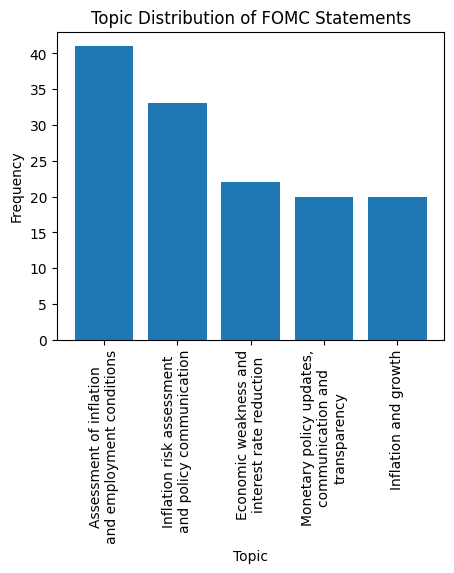

In [66]:
## Visualisation of top 5 topic distribution of FOMC statements.
import textwrap
tpc = ['\n'.join(textwrap.wrap(topic, 25)) for topic in W1.value_counts('Topic')[0:5].index.tolist()]
frequency=W1.value_counts('Topic')[0:5].values.tolist()


plt.figure(figsize=(5,4))
plt.bar(tpc, frequency)
plt.xlabel('Topic')
plt.ylabel('Frequency')
plt.title('Topic Distribution of FOMC Statements')
plt.xticks(rotation=90)
plt.show()



In [67]:
## Performing similar exercise of topic modelling on Minutes.

## Creating document list.
doc = list((fomc_clean_df[fomc_clean_df['Type']=='Minute']['Cleaned_Text']))

# To create TF-IDF matrix of document.
tfidf = tfidf_vectorize.fit_transform(doc)

## Create dataframe of tfidf matrix.
tfidf_df = pd.DataFrame(tfidf.toarray())

## Extracting feature names.
cols = tfidf_vectorize.get_feature_names_out()
tfidf_df.columns=cols
print(len(doc)) ## Check number of FOMC statements
tfidf_df

239


,aaarate,aarated,aaronson,ab,abandon,abate,abatement,abcp,aberration,abet,...,zealand,zero,zerocovid,zeynep,zickler,zikes,zina,zlate,zobel,zone
0,0.0,0.0,0.019787,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.0,0.017999,0.0,0.033438,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.0,0.013263,0.0,0.000000,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.029095,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.0,0.013233,0.0,0.024584,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.020536,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.022802,0.00000,0.0,0.018681,0.0,0.000000,0.0,0.030235,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.0,0.014182,0.0,0.000000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,0.0,0.0,0.000000,0.0,0.00000,0.018247,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
235,0.0,0.0,0.000000,0.0,0.05216,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.02329,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
236,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
237,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0


### There are 238 minutes and 6141 terms in the corpus.

In [68]:
## Set topic_number to 10.

num_topics1 = 10
nmf_model1 = NMF(n_components=num_topics1, random_state=40)

## Decomposing doc-term matrix usng NMF.
W1 = nmf_model1.fit_transform(tfidf)  ## W is Doc-topic matirx
H1 = nmf_model1.components_           ## H is topic-term matirx

print('Rows and Column of W matrix: ',np.shape(W1))  ## W matrix is of dimension 220 X 10
print('Rows and Column of H matrix: ',np.shape(H1))  ## H matrix is of dimension 10 X 1048

##Listing out top 20 words(based on highest value) of each topic row .
word1=np.zeros((10,20)).astype('str')
cols1=tfidf_vectorize.get_feature_names_out()
for i in range(0,num_topics1):
  word1[i]=(cols1[np.argsort(H1[i])[::-1]][:20])

## Creating dataframe of top 20 words of each topic.
pd.DataFrame(word1,index=[ f'Topic{i+1}' for i in range(0,num_topics1)] , \
                 columns=[f'Word{i+1}' for i in range(0,20)])

Rows and Column of W matrix:  (239, 10)
Rows and Column of H matrix:  (10, 6165)


,Word1,Word2,Word3,Word4,Word5,Word6,Word7,Word8,Word9,Word10,Word11,Word12,Word13,Word14,Word15,Word16,Word17,Word18,Word19,Word20
Topic1,participant,members,credit,loan,range,tariff,adviser,appropriate,observe,restrictive,return,goal,special,supply,assess,rrp,delinquency,stance,remark,real
Topic2,mr,ms,expansion,messrs,inventory,sale,equipment,messr,productivity,core,greenspan,gramlich,anecdotal,software,weakness,ferguson,sustainable,relatively,foreseeable,stock
Topic3,shall,december,subcommittee,paragraph,arrangement,authorization,chairman,january,fourth,select,authorize,consultation,pursuant,drawing,swap,million,undertake,november,agreement,feasible
Topic4,july,august,june,september,second,real,secondquarter,participant,half,vehicle,motor,sale,post,hurricane,credit,forward,investor,indicator,lead,summer
Topic5,purchase,participant,asset,program,recovery,loan,guidance,improvement,longerterm,mandate,mbs,credit,appropriate,fiscal,real,debt,threshold,longerrun,stable,accommodation
Topic6,mr,credit,participant,ms,liquidity,messrs,facility,real,april,core,sale,strain,loan,institution,arrangement,commodity,drop,commercial,headline,home
Topic7,october,november,september,december,participant,hurricane,august,thirdquarter,real,fourth,summer,survey,range,solid,longerterm,credit,hurricanerelate,construction,gradual,judge
Topic8,participant,pandemic,coronavirus,purchase,virus,vaccination,goal,repo,range,asset,outbreak,credit,prepandemic,accommodative,health,facility,guidance,mbs,smooth,appropriate
Topic9,january,february,march,fourth,iraq,war,weather,december,oil,geopolitical,winter,outbreak,especially,sale,east,major,equipment,relatively,hightech,vehicle
Topic10,participant,range,real,april,longerrun,normalization,march,gdp,run,june,survey,indicator,projection,medium,pce,appropriate,marketbase,judge,assessment,desk


### Below topics are identified after applying NFM algortihm on FOMC Minutes.


Topic1 = Assessment of credit, loan conditions and policy stance<br>
Topic2 = Investment and sustainable economic growth<br>
Topic3 = Committee consultations, agreements, and authorisations<br>
Topic4 = Motor vehicle sales and mid-year economic activity<br>
Topic5 = Economic recovery and credit support<br>
Topic6 = Liquidity drop, economy stress and credit conditions<br>
Topic7 = Hurricane-related impacts and third quarter economic activity<br>
Topic8 = Pandemic impacts on credit condition and policy guidance<br>
Topic9 = Geopolitical stress, oil sales, and economic activity<br>
Topic10 = Assessment of GDP and policy normalization<br>


In [69]:
# To find max frequency of Topic number in document-term matrix.
W1 = pd.DataFrame(W1, columns=[f'Topic{i + 1}' for i in range(0,num_topics1)]) ## Creating dataframe of W2 matrix.

## Adding new column that assigns Topic Category with highest frequency number.
W1['Max_Topic_Category']=[(W1.iloc[i]).sort_values(ascending=False).index[0] for i in range(0,W1.shape[0])]
W1.value_counts('Max_Topic_Category')  ## To check frequent topic occuring in Minutes.


,count
Max_Topic_Category,
Topic2,49
Topic10,40
Topic1,32
Topic5,29
Topic3,27
Topic6,26
Topic8,15
Topic4,9
Topic9,8


In [70]:
## Assign topic names in Max_Topic_Catrgory column

topic_map = {
    'Topic1': 'Assessment of credit, loan conditions and policy stance',
    'Topic2': 'Investment and sustainable economic growth',
    'Topic3': 'Committee consultations, agreements, and authorisations',
    'Topic4': 'Motor vehicle sales and mid-year economic activity',
    'Topic5': 'Economic recovery and credit support',
    'Topic6': 'Liquidity drop, economy stress and credit conditions',
    'Topic7': 'Hurricane-related impacts and third quarter economic activity',
    'Topic8': 'Pandemic impacts on credit condition and policy guidance',
    'Topic9': 'Geopolitical stress, oil sales, and economic activity',
    'Topic10': 'Assessment of GDP and policy normalization'
}

##Assigning Category name to each compliant.
W1['Topic'] =W1['Max_Topic_Category'].replace(topic_map)
W1.value_counts('Topic')

,count
Topic,
Investment and sustainable economic growth,49
Assessment of GDP and policy normalization,40
"Assessment of credit, loan conditions and policy stance",32
Economic recovery and credit support,29
"Committee consultations, agreements, and authorisations",27
"Liquidity drop, economy stress and credit conditions",26
Pandemic impacts on credit condition and policy guidance,15
Motor vehicle sales and mid-year economic activity,9
"Geopolitical stress, oil sales, and economic activity",8


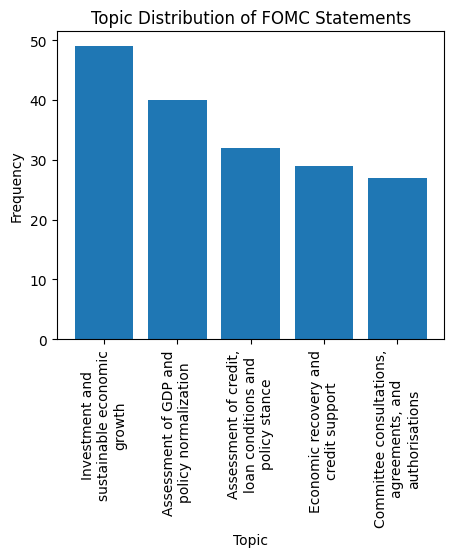

In [71]:
## Visualisation of topic name distribution of FOMC Minute.


tpc = ['\n'.join(textwrap.wrap(topic, 25)) for topic in W1.value_counts('Topic')[0:5].index.tolist()]
frequency=W1.value_counts('Topic')[0:5].values.tolist()


plt.figure(figsize=(5,4))
plt.bar(tpc, frequency)
plt.xlabel('Topic')
plt.ylabel('Frequency')
plt.title('Topic Distribution of FOMC Statements')
plt.xticks(rotation=90)
plt.show()

### Observations from Statements :-<br>
### 1. Documents with a focus on the assessment of the economic market condition based on  inflation and employment rate. <br>

###2. It covers the future policy stance based on the risks and goals communicated by members.  <br>
### 3. Topic related to economic weakness and the activity related to the Reserve Bank growth. <br>
###4. Focus on key macroeconomic indicators, including employment, treasury, inflation, and prices, for future policy guidance.

### Observations from Minutes :-<br>
### 1. nvestment in equipment and software, and the prospect of economic growth, are the key focus of these minutes. <br>

###2. It covers Surveys, GDP assessment, and policy normalization <br>
### 3. Minutes covering credit, loans, delinquency, and future policy amendments related to these topics <br>
###4. Focus on key macroeconomic indicators, including employment, treasury, inflation, and prices, for future policy guidance.<br>
#### 5. Primarily focuses on credit, debt, and loan recovery for a stable economy.  